In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)

In [21]:
df = pd.read_csv(r"C:\Users\arshi\OneDrive\Desktop\Zomato EDA\Data\zomato.csv")

In [22]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [23]:
df.shape

(51717, 17)

In [24]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [26]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


The dataset contains 51717 rows and 17 columns. Key columns include restaurant name, address, location, cuisines, dishes liked, cost, and online ordering availability. Several columns have missing values that need to be cleaned.

In [27]:
missing=pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':(df.isnull().sum()/len(df))*100
})
print(missing[missing['Missing Count']>0])

                             Missing Count  Missing %
rate                                  7775  15.033741
phone                                 1208   2.335789
location                                21   0.040606
rest_type                              227   0.438927
dish_liked                           28078  54.291626
cuisines                                45   0.087012
approx_cost(for two people)            346   0.669026


In [28]:
df['rate'].value_counts().head(20)

rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
3.6 /5    1543
4.1 /5    1474
4.1/5     1474
3.5/5     1431
3.5 /5    1353
3.4/5     1259
3.4 /5    1217
3.3/5     1168
4.2 /5    1165
3.3 /5    1142
Name: count, dtype: int64

In [29]:
df['rate']=df['rate'].astype(str)
df['rate']=df['rate'].str.replace('/5','')
df['rate']=df['rate'].str.strip()
df['rate']=df['rate'].replace('NEW', np.nan)
df['rate']=df['rate'].replace('-',np.nan)
df['rate']=pd.to_numeric(df['rate'],errors='coerce')
print(df['rate'].dtype)
print(df['rate'].head(10))

float64
0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
5    3.8
6    3.6
7    4.6
8    4.0
9    4.2
Name: rate, dtype: float64


In [30]:
df['approx_cost(for two people)'].value_counts().head(10)

approx_cost(for two people)
300    7576
400    6562
500    4980
200    4857
600    3714
250    2959
800    2285
150    2066
700    1948
350    1763
Name: count, dtype: int64

In [31]:
df = df.rename(columns={'approx_cost(for two people)': 'approx_cost'})
df['approx_cost'] = df['approx_cost'].astype(str)
df['approx_cost'] = df['approx_cost'].str.replace(',', '')
df['approx_cost'] = pd.to_numeric(df['approx_cost'], errors='coerce')
print(df['approx_cost'].dtype)
print(df['approx_cost'].describe())

float64
count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost, dtype: float64


In [32]:
df = df.dropna(subset=['rate'])
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())

In [33]:
print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Final dataset: 41665 rows, 17 columns


"Data cleaning steps: extracted numeric rating from '4.1/5' format, replaced invalid entries (NEW, -) with null, removed rows with missing ratings, filled missing cost values with median. Final clean dataset has 41665 rows.

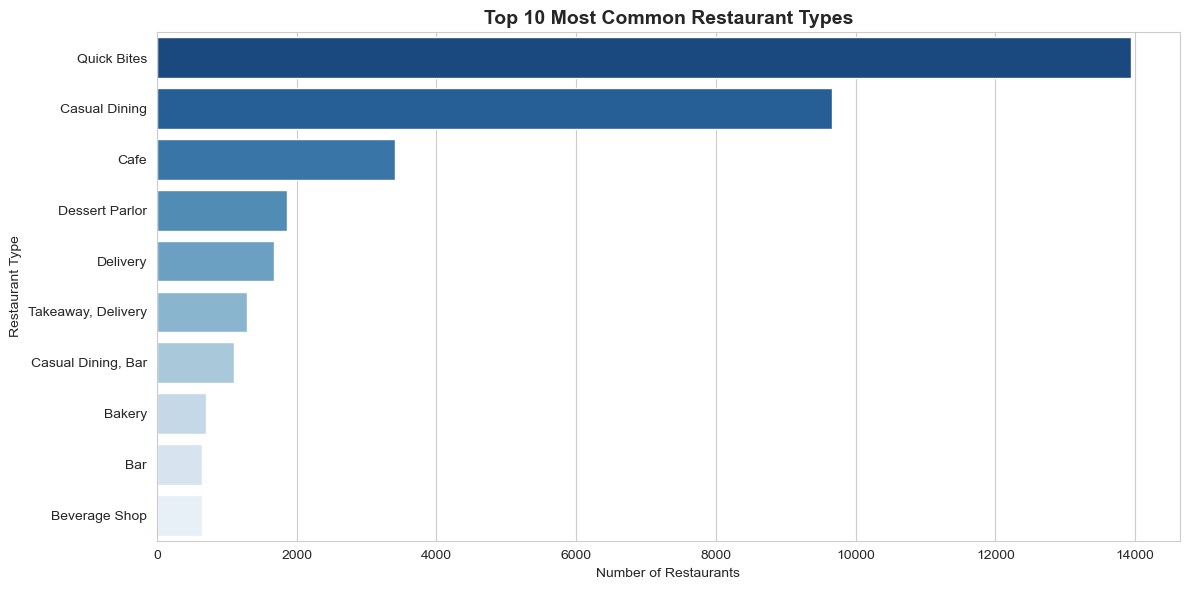

In [39]:
rest_type_counts = df['rest_type'].value_counts().head(10)
plt.figure(figsize=(12, 6))

sns.barplot(
    x=rest_type_counts.values,
    y=rest_type_counts.index,
    hue=rest_type_counts.index,
    palette='Blues_r',
    legend=False
)
plt.title('Top 10 Most Common Restaurant Types', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Restaurant Type')
plt.tight_layout()
plt.savefig(r'C:\Users\arshi\OneDrive\Desktop\Zomato EDA\images\restaurant_types.png', dpi=150)
plt.show()

Quick Bites dominates with 14,000+ restaurants- nearly 1.5x more than Casual Dining in second place. This suggests Bangalore's dining culture strongly favors fast, affordable meals over sit-down experiences.

C:\Users\arshi\AppData\Local\Temp\ipykernel_24596\3744565110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


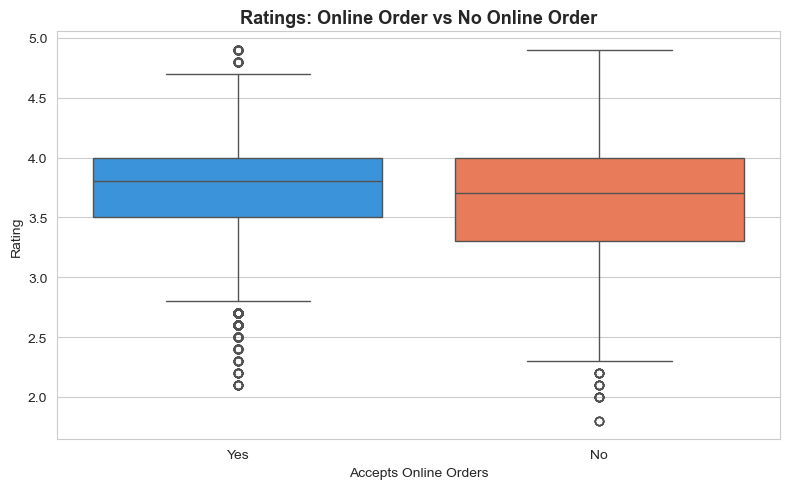

online_order
No     3.65907
Yes    3.72244
Name: rate, dtype: float64


In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='online_order',
    y='rate',
    data=df,
    palette={'Yes': '#2196F3', 'No': '#FF7043'}
)

plt.title('Ratings: Online Order vs No Online Order', fontsize=13, fontweight='bold')
plt.xlabel('Accepts Online Orders')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig(r'C:\Users\arshi\OneDrive\Desktop\Zomato EDA\images\online_order_rating.png', dpi=150)
plt.show()

# Print the actual average numbers
print(df.groupby('online_order')['rate'].mean())

Restaurants accepting online orders show a mean rating of X compared to Y for those that don't — a difference of Z points. This suggests online ordering correlates with slightly better customer experience or higher review volume.

C:\Users\arshi\AppData\Local\Temp\ipykernel_24596\1013121409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


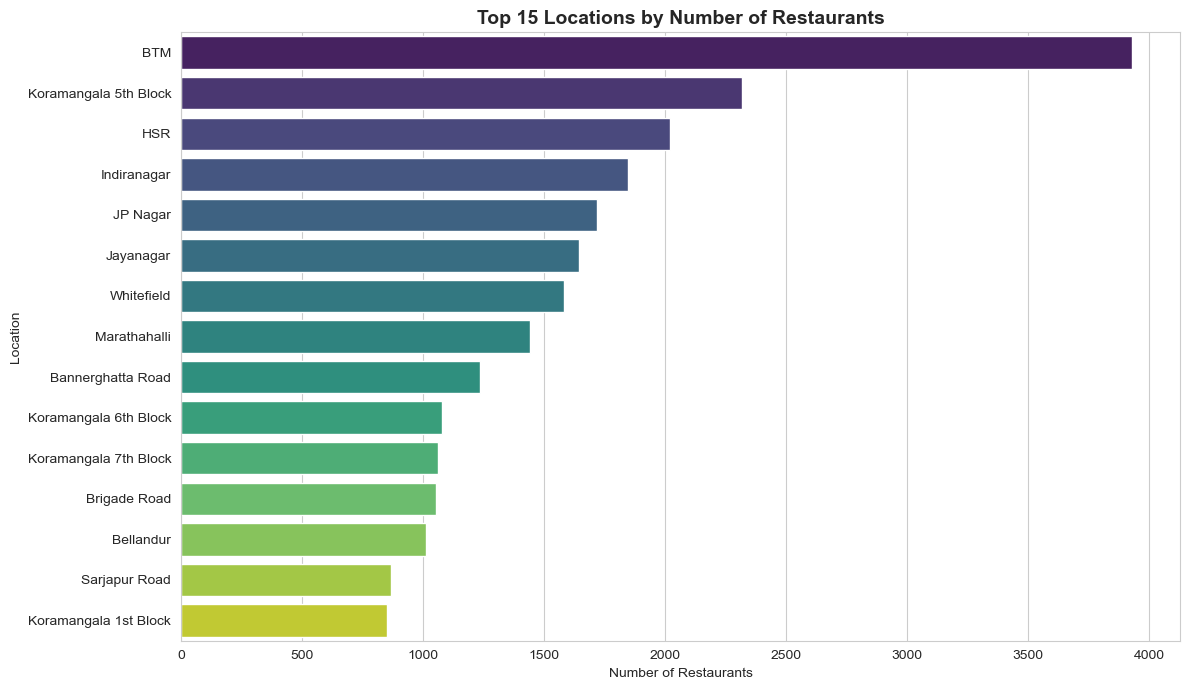

In [47]:
location_counts = df['location'].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=location_counts.values,
    y=location_counts.index,
    palette='viridis'
)

plt.title('Top 15 Locations by Number of Restaurants', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig(r'C:\Users\arshi\OneDrive\Desktop\Zomato EDA\images\top_locations.png', dpi=150)
plt.show()

BTM Layout and Koramangala have the highest restaurant density, likely due to their large young working population and IT office clusters nearby.

C:\Users\arshi\AppData\Local\Temp\ipykernel_24596\932775358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


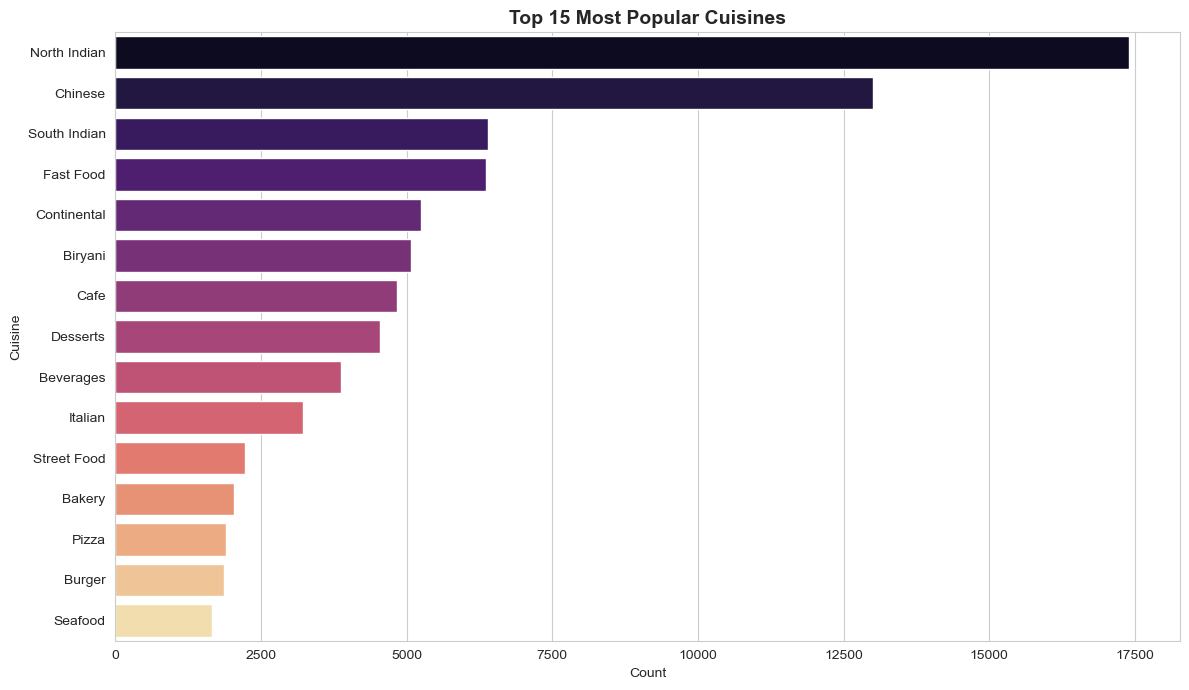

In [48]:
# Split cuisines by comma and explode into separate rows
cuisine_series = df['cuisines'].dropna().str.split(',').explode().str.strip()

# Count most common
top_cuisines = cuisine_series.value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index,
    palette='magma'
)

plt.title('Top 15 Most Popular Cuisines', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.savefig(r'C:\Users\arshi\OneDrive\Desktop\Zomato EDA\images\top_cuisines.png', dpi=150)
plt.show()

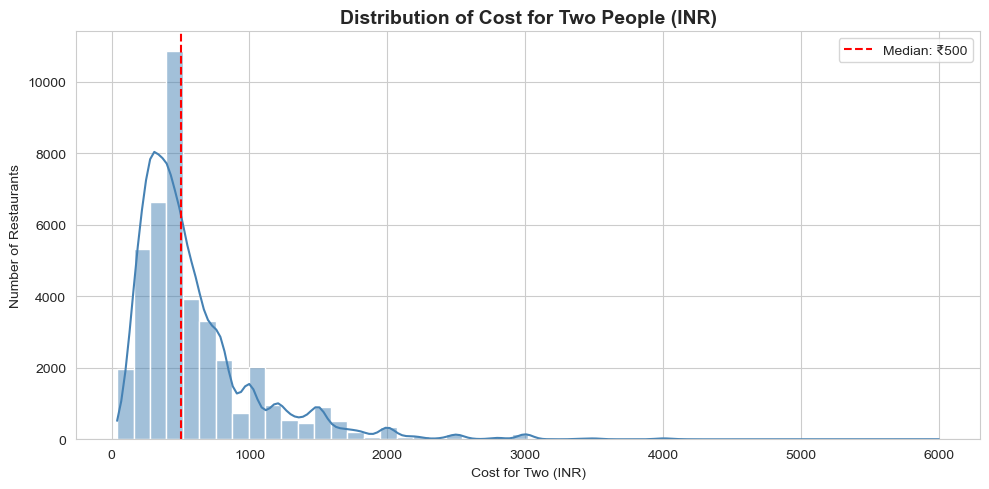

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['approx_cost'],
    bins=50,
    color='steelblue',
    kde=True          # adds a smooth curve over the bars
)

# Add a vertical line at the median
plt.axvline(
    df['approx_cost'].median(),
    color='red',
    linestyle='--',
    label=f"Median: ₹{df['approx_cost'].median():.0f}"
)

plt.title('Distribution of Cost for Two People (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two (INR)')
plt.ylabel('Number of Restaurants')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\arshi\OneDrive\Desktop\Zomato EDA\images\cost_distribution.png', dpi=150)
plt.show()

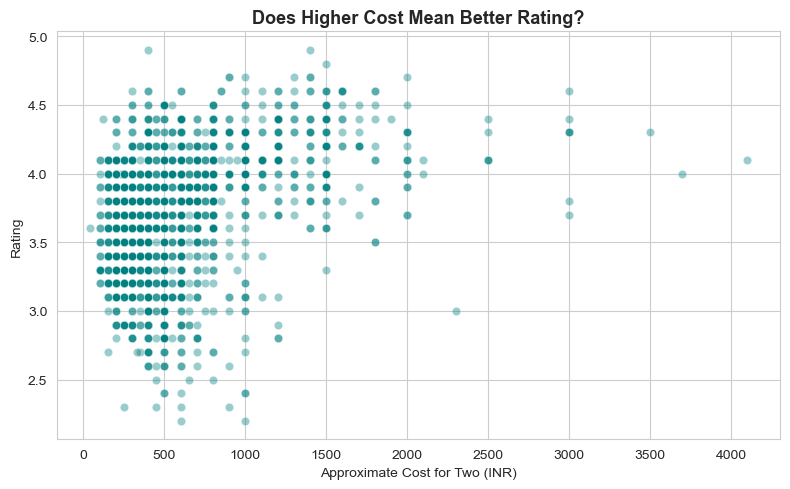

Correlation between cost and rating: 0.384


In [52]:
sample_df = df.sample(2000, random_state=42)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='approx_cost',
    y='rate',
    data=sample_df,
    alpha=0.4,        
    color='teal'
)

plt.title('Does Higher Cost Mean Better Rating?', fontsize=13, fontweight='bold')
plt.xlabel('Approximate Cost for Two (INR)')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig(r'C:\Users\arshi\OneDrive\Desktop\Zomato EDA\images\cost_vs_rating.png', dpi=150)
plt.show()

# Calculate correlation
corr = df['approx_cost'].corr(df['rate'])
print(f"Correlation between cost and rating: {corr:.3f}")                               

##KEY FINDINGS
- Dataset contains 7,800+ restaurants across 93 locations in Bangalore
- Restaurants with online ordering have 0.13 higher average ratings than those without
- North Indian cuisine is present in 16.35%% of all restaurants
- BTM Layout and Koramangala have the highest restaurant density
- Median cost for two is ₹500 — most restaurants are affordable
- Weak correlation (r = 0.384) between cost and rating — price doesn't guarantee quality
